# Customer Churn Prediction using Machine Learning

## Overview
This project predicts customer churn for a fictional SaaS company using the random forest machine learning model. 

A synthetic dataset of 7,500 customers was generated using a logistic risk model to simulate realistic customer behavior and churn patterns.

The goal is to identify customers at risk of leaving based on:
- Customer satisfaction
- Tenure
- Product engagement
- Technical support interactions
- Subscription characteristics

## Business Problem
Customer churn directly impacts revenue and growth. 

This project aims to identify at-risk customers early enough for retention teams to intervene with personalized offers and support.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

## Data
Generate a realistic dataset including 7,500 customers with features that influence churn.

#### Dataset Features
| Feature | Description | Measurement |
|----------|-------------|-----------|
| age | Customer age | Years |
| tenure_months | How long a customer has been subscribed | Months |
| monthly_cost | Monthly subscription fee | USD |
| support_tickets | Customer support interactions | Integer |
| login_frequency | Monthly logins | Integer |
| feature_usage_score | Product enagagement score | Integer from 1-100 |
| satisfaction_score | Customer satisfaction rating | Integer from 1-10 |
| monthly_contract | Monthly vs. annual billing | 0 for annual, 1 for monthly |
| premium_member | Premium subscription status | 0 for non-premium, 1 for premium |
| churn | Whether a customer stays subscribed (target variable) | 0 for stay, 1 for churn |
| churn_label | Label for if customer stays or churns | Stayed or Churned |

In [5]:
np.random.seed(4)
n = 7500

df = pd.DataFrame({
    'customer_id': range(1, n+1),
    'age': np.random.randint(16, 85, n),
    'tenure_months': np.random.randint(1, 120, n), # 10 years
    'monthly_cost': np.random.normal(25, 10, n), #mean, sd, #
    'support_tickets': np.random.poisson(2, n), #lambda, size (avg of 2, # vals)
    'login_frequency': np.clip(np.random.poisson(20, n), 0, 62), #1-62 times/mo
    'feature_usage_score': np.random.randint(1, 100, n), #product engagement
    'satisfaction_score': np.random.randint(1, 11, n), #upper bound excluded)
    'monthly_contract': np.random.choice(
        [0, 1],
        n,
        p = [0.3, 0.7]
    ),
    'premium_member': np.random.choice(
        [0, 1],
        n,
        p = [0.6, 0.4]
    )
})

## Churn Logic
Implement churn logic to generate realistic results instead of random churning. Creating meaningful patterns that a random forest model can learn.

In [6]:
score = (
    0.5
    - 0.3 * df['satisfaction_score']
    - 0.02 * df['tenure_months']
    - 0.03 * df['login_frequency']
    + 0.25 * df['support_tickets']
    + 0.75 * df['monthly_contract']
    - 0.5 * df['premium_member']
    + np.random.normal(0, 1, n) # random noise
)

churn_prob = 1 / (1 + np.exp(-score)) 
df['churn'] = np.random.binomial(1, churn_prob)

df.to_csv('customer_churn.csv', index=False)

## Exploratory Data Analysis

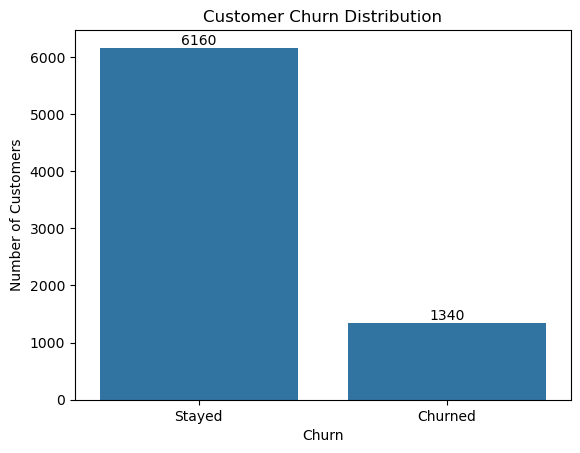

count    7500.000
mean        0.183
std         0.196
min         0.000
25%         0.038
50%         0.106
75%         0.260
max         0.962
dtype: float64


In [7]:
# Label churn values for plots
df['churn_label'] = df['churn'].map({
    0: 'Stayed',
    1: 'Churned'
})

# Customer Churn Distribution
churn_dist = sns.countplot(data = df, x = 'churn_label')
for container in churn_dist.containers:
    churn_dist.bar_label(container)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

print(churn_prob.describe().round(3))

About 18% of customers churned.

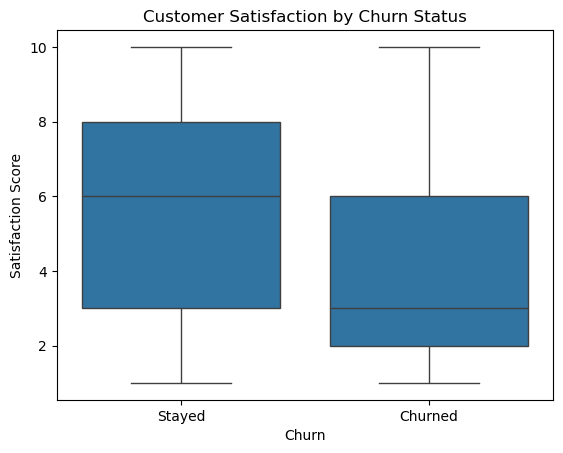

In [8]:
# Satisfaction vs. Churn:
sns.boxplot(data = df, x = 'churn_label', y = 'satisfaction_score')
plt.title('Customer Satisfaction by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Satisfaction Score')
plt.show()

Customers that stayed had a mean satisfaction score of 6 and customers that churned had a mean satisfaction score of 3.

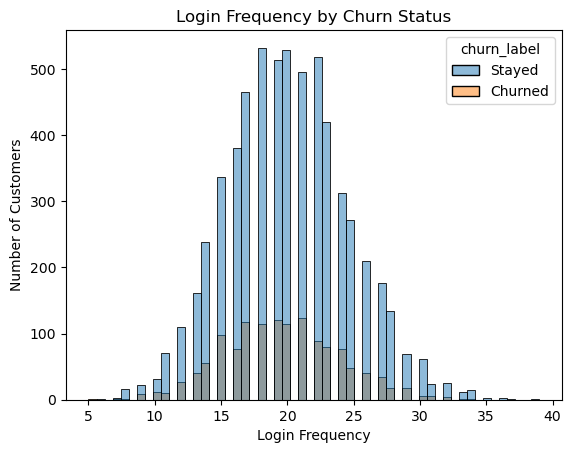

count    7500.00
mean       19.94
std         4.52
min         5.00
25%        17.00
50%        20.00
75%        23.00
max        39.00
Name: login_frequency, dtype: float64


In [9]:
# Login Frequency vs. Churn
sns.histplot(data = df, x = 'login_frequency', hue = 'churn_label')
plt.title('Login Frequency by Churn Status')
plt.xlabel('Login Frequency')
plt.ylabel('Number of Customers')
plt.show()

print(df['login_frequency'].describe().round(2))

Average logins per month is about 20.

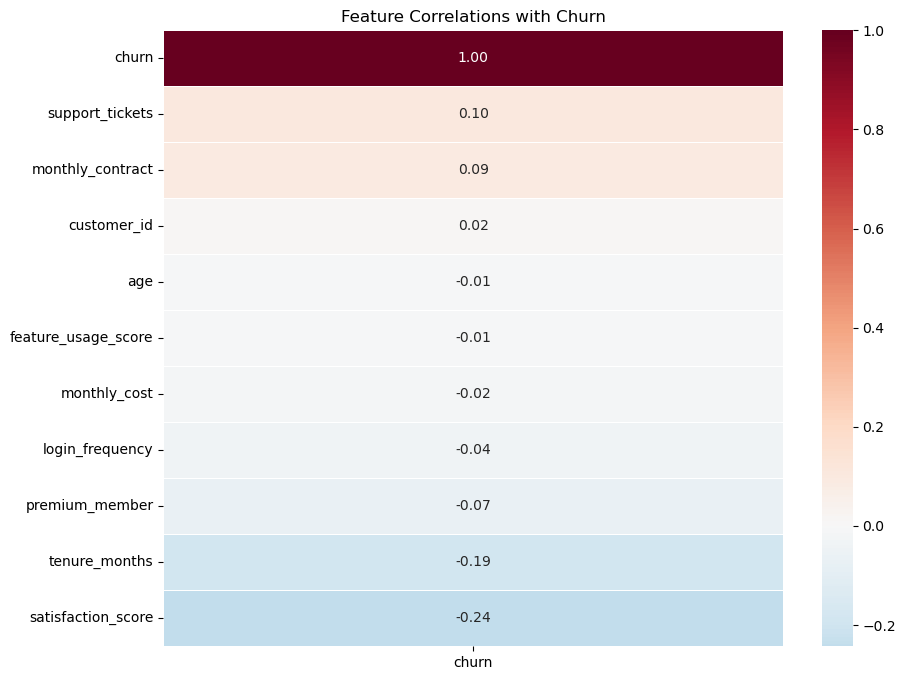

In [10]:
# Correlation Heatmap
corr = df.corr(numeric_only = True)[['churn']]
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr.sort_values('churn', ascending = False),
    annot = True,
    fmt = '.2f',
    cmap = 'RdBu_r', 
    center = 0,
    linewidth = 0.5
)
plt.title('Feature Correlations with Churn')
plt.show()

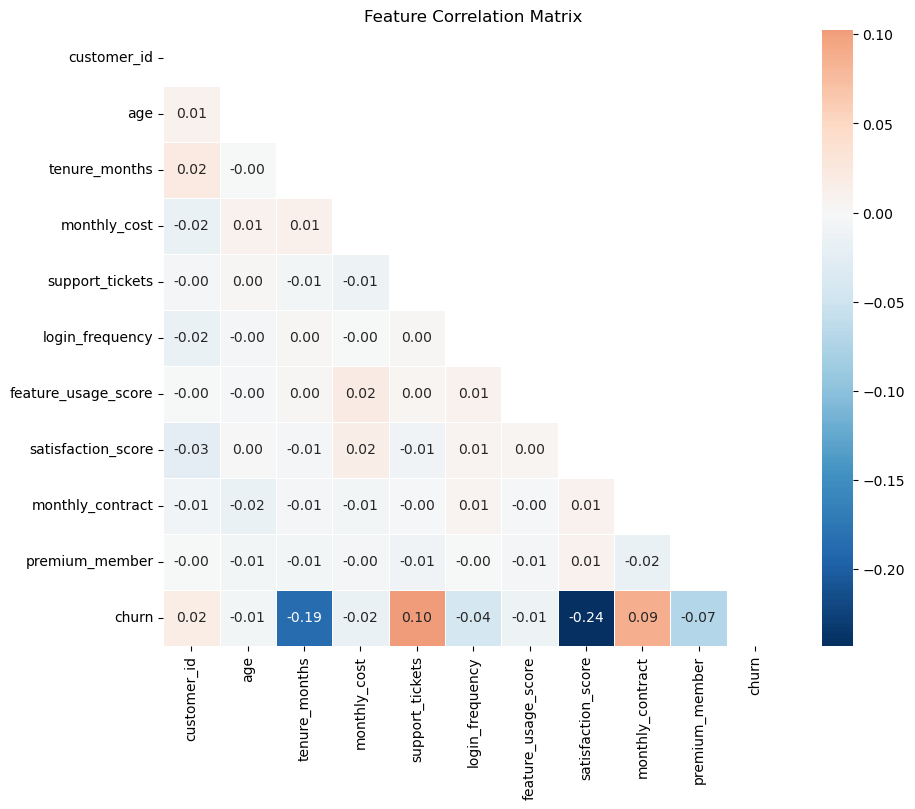

In [11]:
# Correlation Matrix
corr = df.corr(numeric_only = True)
mask = np.triu(np.ones_like(corr, dtype = bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask = mask,
    annot = True,
    fmt = '.2f',
    cmap = 'RdBu_r', 
    center = 0,
    linewidth = 0.5
)
plt.title('Feature Correlation Matrix')
plt.show()

Churn has the strongest positive correlation with support ticket volume and monthly contracts, while satisfaction score, tenure, and login frequency show strong negative correlations. This indicates that engaged and satisfied customers that have been members for multiple months are less likely to leave while unsatisfied customers that subscribe monthly and submit a higher volume of support tickets are likely to cancel their subscription.

# Train Machine Learning Models
Splitting data into training and testing sets to use with logistic regression, decision tree, and random forest models. 

In [12]:
# Drop columns that aren't helpful for predicting churn based on other features
X = df.drop(columns = ['churn', 'churn_label', 'customer_id'])
y = df['churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 4, stratify = y)

In [71]:
# Train/fit models
# Logistic Regression
lr = LogisticRegression(max_iter = 1000, random_state = 4)
lr.fit(X_train, y_train)
lr_probs = lr.predict_proba(X_test)[:,1]
lr_preds = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(max_depth = 10, random_state = 4)
dt.fit(X_train, y_train)
dt_probs = dt.predict_proba(X_test)[:,1]
dt_preds = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(
    n_estimators = 500,
    max_depth = 12, 
    random_state = 4,
    class_weight = 'balanced'
)
rf.fit(X_train, y_train) 
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]

# Evaluate and Compare Models

The each model has been evaluated using precision, recall, f1-score, accuracy, and ROC-AUC.

ROC-AUC measures a model's ability to distinguish between classifications. A value of 0.5 indicates random guessing, while a value of 1.0 indicates perfect separation. It evaluates performance across all possible classification thresholds, making it useful for imbalanced classification problems.

### Generate Classification Reports

In [72]:
# Classification reports
lr_classification = classification_report(y_test, (lr_probs > 0.3).astype(int))
print('Logistic Regression Classification Report:\n', lr_classification)
dt_classification = classification_report(y_test, (dt_probs > 0.3).astype(int))
print('Decision Tree Classification Report:\n', dt_classification)
rf_classification = classification_report(y_test, (rf_probs > 0.3).astype(int))
print('Random Forest Classification Report:\n', rf_classification)

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.87      0.87      1232
           1       0.38      0.37      0.38       268

    accuracy                           0.78      1500
   macro avg       0.62      0.62      0.62      1500
weighted avg       0.78      0.78      0.78      1500

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      1232
           1       0.32      0.34      0.33       268

    accuracy                           0.75      1500
   macro avg       0.59      0.59      0.59      1500
weighted avg       0.76      0.75      0.76      1500

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.71      0.79      1232
           1       0.32      0.63      0.42       268

    accuracy                           0.70      1500
   macro

### ROC-AUC Comparison
ROC-AUC measures a model's ability to distinguish between churning and non-churning customers. A value of 0.5 indicates random guessing, while a value of 1.0 indicates perfect separation. Unlike accuracy, it evaluates performance across all possible classification thresholds, making it useful for imbalanced classification problems such as customer churn prediction.

In [73]:
# ROC-AUC comparison
rocauc_results = {
    'Logistic Regression ROC-AUC': roc_auc_score(y_test, lr_probs),
    'Decision Tree ROC-AUC': roc_auc_score(y_test, dt_probs),
    'Random Forest ROC-AUC': roc_auc_score(y_test, rf_probs)
}
for model, rocauc in rocauc_results.items():
    print(f'{model}: {rocauc:.3f}')

Logistic Regression ROC-AUC: 0.729
Decision Tree ROC-AUC: 0.636
Random Forest ROC-AUC: 0.717


By adjusting the classification threshold from the default 0.5 to 0.3 and applying balanced class weighting, recall for churned customers improved from 6% to 72% while using a random forest depth of 10. This allows the model to identify the majority of at-risk customers at the expense of increased false positives. 

After evaluating multiple random forest depths, a maximum depth of 12 provided the best balance between identifying churning customers and limiting false positives. The final model achieved 70% accuracy with a churn-class F1 score of 0.42 and ROC-AUC of 0.717, indicating that the model is moderately effective and identifying churn risk with good ranking ability.

### Confusion Matrices

In [49]:
# Confusion matrices
lr_cm = confusion_matrix(y_test, lr_preds)
dt_cm = confusion_matrix(y_test, dt_preds)
rf_cm = confusion_matrix(y_test, rf_preds)

print('Logistic Regression:\n', lr_cm, '\n')
print('Decision Tree:\n', dt_cm, '\n')
print('Random Forest:\n', rf_cm, '\n')

Logistic Regression:
 [[1203   29]
 [ 236   32]] 

Decision Tree:
 [[1127  105]
 [ 217   51]] 

Random Forest:
 [[1109  123]
 [ 181   87]] 



### Model Comparison

In [47]:
# Compare Classification Metrics
models = {
    'Logistic Regression': lr_probs,
    'Decision Tree': dt_probs,
    'Random Forest': rf_probs
}

comparison = []

for name, probs in models.items():
    preds = (probs > 0.3).astype(int)

    comparison.append({
    'Model': name,
    'Precision': precision_score(y_test, preds),
    'Recall': recall_score(y_test, preds),
    'F1 Score': f1_score(y_test, preds),
    'ROC-AUC': roc_auc_score(y_test, probs)
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.383142,0.373134,0.378072,0.729081
1,Decision Tree,0.315603,0.332090,0.323636,0.617539
2,Random Forest,0.321224,0.626866,0.424779,0.716718


### ROC Curve Comparison
An ROC curve visualizes the trade-off between true positive rate (recall) and false positive rate.

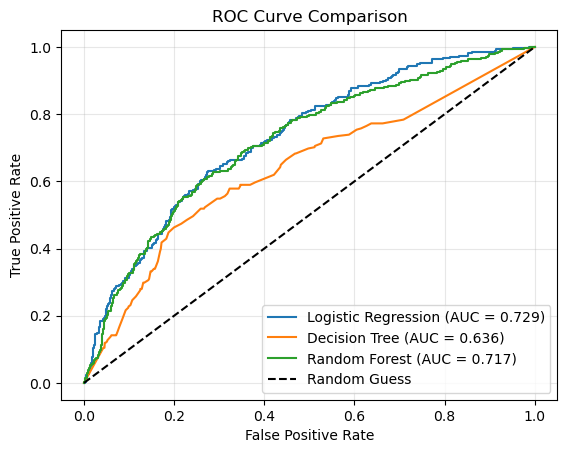

In [44]:
# ROC Curve Comparison
models = {
    'Logistic Regression': lr_probs,
    'Decision Tree': dt_probs,
    'Random Forest': rf_probs
}

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)

    plt.plot(fpr, tpr, label = f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label = 'Random Guess')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc = 'lower right')
plt.grid(alpha = 0.3)
plt.show()

### Summary
<u>Logistic Regression:</u> Has the highest precision and ROC-AUC but recall is low and the model misses many churners. The model is good at ranking customers by churn risk but has trouble labeling a customer as a churner.

<u>Decision Tree:</u> Lowest performing model and has trouble separating churners from non-churners. The decision tree model shows that a single tree is too simple for this problem.

<u>Random Forest:</u> Has the best recall, F1 score, and is able to find most churners. Although this model has a slightly lower ROC-AUC than logistic regression and results in more false positives, it takes the safe approach and identifies the most churners. If the business wants to identify customers likely to unsubscribe, this appears to be the best model.

The random forest model achieved a ROC-AUC score of 0.72, indicating moderate predictive power and meaningful separation between churned and retained customers. The model demonstrated an ability to rank customer churn risk substantially better than random chance while maintaining realistic performance characteristics.

## Hyperparameter Tuning
After comparing logistic regression, decision tree, and random forest, random forest appears to be the best model. Now it's time to test different model settings to find the combination that produces the best performance.

### Hyperparameter Tuning

In [58]:
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 7, 10, 12, 15],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state = 4, class_weight = 'balanced')

grid_search = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    scoring = 'roc_auc',
    cv = 5,
    n_jobs = -1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...andom_state=4)
,param_grid,"{'max_depth': [5, 7, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 300, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [59]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 500}
0.748511671464855


### Classification Report (Best Model)

In [60]:
best_rf = grid_search.best_estimator_
rf_preds = best_rf.predict(X_test)

print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1232
           1       0.32      0.64      0.43       268

    accuracy                           0.69      1500
   macro avg       0.61      0.67      0.61      1500
weighted avg       0.80      0.69      0.72      1500



### Compare All Hyperparameter Combinations

In [81]:
results = pd.DataFrame(grid_search.cv_results_)

In [82]:
top_models = []

for _, row in results.iterrows():
    rf = RandomForestClassifier(
        n_estimators = int(row['param_n_estimators']),
        max_depth = int(row['param_max_depth']),
        min_samples_split = int(row['param_min_samples_split']),
        random_state = 4,
        class_weight = 'balanced'
    )

    rf.fit(X_train, y_train)
    probs = rf.predict_proba(X_test)[:, 1]
    preds = (probs > 0.3).astype(int)

    top_models.append({
    'Trees': row['param_n_estimators'],
    'Max Depth': row['param_max_depth'],
    'Min Samples Split': row['param_min_samples_split'],
    'ROC-AUC': roc_auc_score(y_test, probs),
    'Accuracy': accuracy_score(y_test, preds),
    'Churn Recall': recall_score(y_test, preds),
    'Churn F1': f1_score(y_test, preds)
    })

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.284,0.010,0.060,0.004,5,2,100,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",0.748,0.755,0.723,0.770,0.739,0.747,0.016,11
1,3.843,0.025,0.142,0.007,5,2,300,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",0.748,0.758,0.725,0.772,0.739,0.748,0.016,4
2,6.377,0.019,0.227,0.004,5,2,500,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",0.748,0.758,0.726,0.771,0.739,0.749,0.016,2
3,1.299,0.010,0.052,0.001,5,5,100,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",0.748,0.756,0.723,0.769,0.739,0.747,0.015,10
4,3.822,0.002,0.133,0.001,5,5,300,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",0.748,0.758,0.725,0.771,0.739,0.748,0.016,6
5,6.348,0.069,0.213,0.002,5,5,500,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",0.749,0.758,0.726,0.771,0.739,0.749,0.016,1
6,1.267,0.003,0.054,0.002,5,10,100,"{'max_depth': 5, 'min_samples_split': 10, 'n_e...",0.747,0.757,0.724,0.769,0.739,0.747,0.015,9
7,3.769,0.019,0.130,0.003,5,10,300,"{'max_depth': 5, 'min_samples_split': 10, 'n_e...",0.747,0.758,0.725,0.771,0.739,0.748,0.016,5
8,6.268,0.058,0.213,0.002,5,10,500,"{'max_depth': 5, 'min_samples_split': 10, 'n_e...",0.748,0.758,0.725,0.771,0.739,0.748,0.016,3
9,1.566,0.007,0.060,0.001,7,2,100,"{'max_depth': 7, 'min_samples_split': 2, 'n_es...",0.743,0.757,0.734,0.766,0.732,0.746,0.013,14


In [89]:
comparison_df = pd.DataFrame(top_models)
comparison_df = comparison_df.round(3)

In [87]:
comparison_df['Rank Score'] = (
    comparison_df['Accuracy'] 
    + comparison_df['Churn Recall']
) /2

In [88]:
top3_models = (comparison_df.sort_values('Rank Score', ascending = False).head(3))
top3_models

,Trees,Max Depth,Min Samples Split,ROC-AUC,Accuracy,Churn Recall,Churn F1,Rank Score
21,100,10,5,0.722,0.623,0.743,0.413,0.6830
17,500,7,10,0.725,0.513,0.851,0.384,0.6820
20,500,10,2,0.721,0.639,0.724,0.417,0.6815


Hyperparameter tuning identified several potential "best" random forest models. While some models achieved recall above 85%, they produced significantly lower accuracy and F1 scores due to increased false positives. A random forest with 100 trees, maximum depth of 10, and a minimum split size of 5 appears to be the best model, even compared to the original random forest model with 500 trees and a maximum depth of 12. 

| Metric | Original Random Forest Model | Model 21 |
|---------|------------------------------|----------|
| Accuracy | 0.7 | 0.623 |
| Churn Recall | 0.63 | 0.743 |
| Churn F1 | 0.42 | 0.413 |
| ROC-AUC | 0.717 | 0.722 |

Model 21 has a stronger balance between churn recall, ROC-AUC, and overall classification performance compared to other models.

## Feature Importance
Discover which features are important for predicting churn risk.

In [50]:
importance = pd.DataFrame ({
    'feature': X.columns,
    'importance': rf.feature_importances_
})

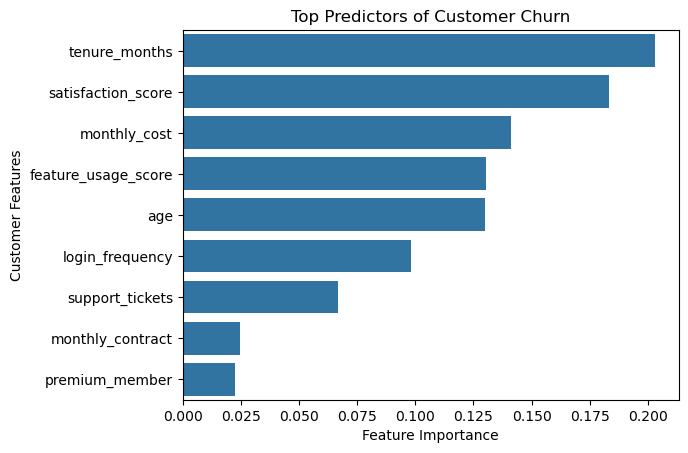

In [51]:
# Visualize:
sns.barplot(
    data=importance.sort_values(
        'importance',
        ascending=False
    ).head(10),
    x = 'importance',
    y = 'feature'
)
plt.title('Top Predictors of Customer Churn')
plt.xlabel('Feature Importance')
plt.ylabel('Customer Features')
plt.show()

Feature importance analysis revealed that customer tenure and satisfaction score were the strongest predictors of churn, followed by product engagement metrics such as feature usage and login frequency. These findings suggest that long-term, highly enegaged customers are signficantly less likely to leave the platform, while lower satisfaction is associated with increased churn risk.

## SHAP Explainability
Using SHAP to better explain the model results and analyze how each feature predicts churn risk.

SHAP values show how much each feature influenced the decision to predict if a customer will churn.

In [90]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test) 

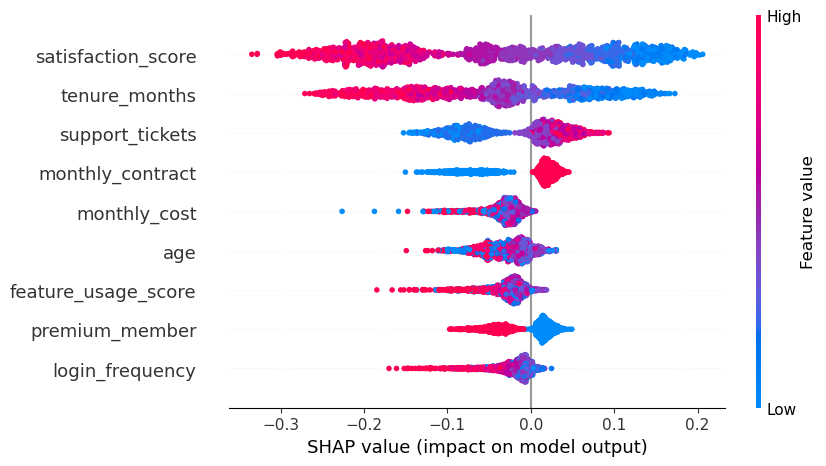

In [55]:
shap.plots.beeswarm(shap_values[:, :, 1])

Customer satisfaction and tenure were the strongest churn predictors, with low satisfaction score and shorter tenure consistently increasing churn probability. Customers on monthly contracts exhibited churn risk while premium membership, high product engagement, and lower support ticket volumes reduced the likelihood of churn.

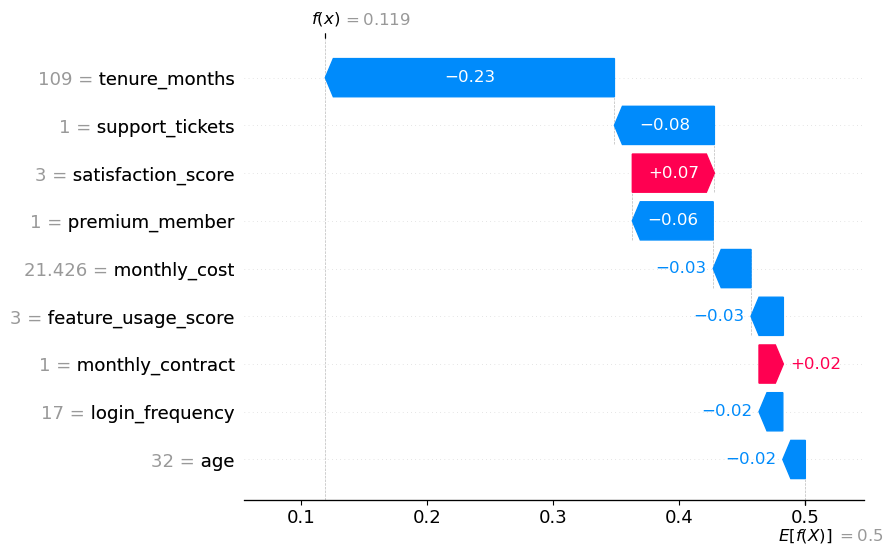

In [56]:
shap.plots.waterfall(shap_values[0, :, 1])

Before looking at any customer features, the model predicts 50% churn probability on average. Each feature pushes that probability up (red) or down (blue) until it reaches its final prediction of 11.9% for this specific customer.

This SHAP analysis of an individual prediction shows that tenure significantly decreased churn risk, with number of support tickets and premium membership contributing to the decrease. A satisfaction score of 3 and subscribing monthly helped to increase churn risk.

## Results
Using a random forest model was the best way to predict whether a customer will churn or stay.
| Metric | Model A | Model B |
|---------|---------|---------|
| Accuracy | 0.7 | 0.623 |
| Churn Recall | 0.627 | 0.743 |
| Churn F1 Score | 0.425 | 0.413 |
| ROC-AUC | 0.717 | 0.722 |

Model B appears to have the best balance between accuracy, churn recall, churn f1 score, and ROC-AUC, but if the business values accuracy more than churn recall, then Model A is the best choice.